# CDS Curve Fitted Using Modified Nelson-Siegel

**Methodology**: https://www.cnb.cz/en/economic-research/research-publications/cnb-working-paper-series/Longer-term-Yield-Decomposition-The-Analysis-of-the-Czech-Government-Yield-Curve

**Formula**: r(t) = β(0) [1-(1-e^(-t/λ​))/(t/λ)] + β(2) [(1-e^(-t/λ​))/(t/λ)-e^(-t/λ​)]

**Instantaneous CDS spread** equal to zero = no default risk, mathematically expressed as β(0) + β(1) = 0

In [ ]:
import matplotlib.pyplot as plt
from scipy.optimize import fmin
import pandas as pd
import numpy as np

# import sample US credit default swap spread data (currency: USD)
# data source: LSEG Workspace
df = pd.read_csv('cds_curve.csv', delimiter=";")
df = df.copy()
df.style.format({"Maturity": "{:,.1f}".format,"CDS": "{:,.2%}".format})

,Maturity,CDS
0,0.0,nan%
1,0.5,0.17%
2,1.0,0.24%
3,2.0,0.29%
4,3.0,0.31%
5,4.0,nan%
6,5.0,0.38%
7,6.0,nan%
8,7.0,0.42%
9,8.0,nan%


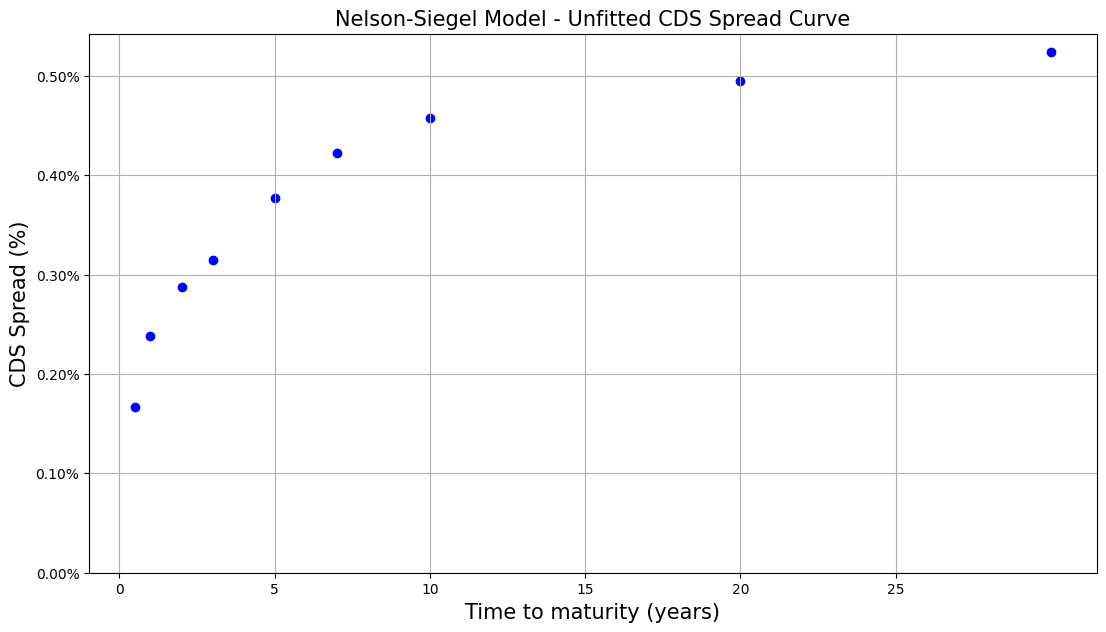

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

sf = df.copy().dropna() # removal of missing values
sf1 = sf.copy() # avoid changing the initial dataset
sf1["Y"] = round(sf1["CDS"]*100, 4)   # CDS spread in percent units

fontsize = 15

fig, ax = plt.subplots(figsize=(13, 7)) # plots original axis
fig.patch.set_facecolor("white") # background label color
ax.set_facecolor("white") # graph background color

ax.set_title("Nelson-Siegel Model - Unfitted CDS Spread Curve", fontsize=fontsize)

X = sf1["Maturity"]
Y = sf1["Y"]

ax.scatter(X, Y, marker="o", color="blue")
# plots datapoints within the graph
# use ax.plot for a connected scatterplot, linestyle = '-'
# use ax.plot for a line chart, marker = "", linestyle = '-'
ax.set_xlabel("Time to maturity (years)", fontsize=fontsize)
ax.set_ylabel("CDS Spread (%)", fontsize=fontsize)

# Y values are already in percent units, so use xmax=100 for % y-axis format
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

ax.set_xticks(np.arange(0, 30, 5)) # first tick, last tick, gaps
ax.set_yticks(np.arange(0, 0.6, 0.1))

ax.grid(True)

plt.show()
# visualization of observed CDS data

In [ ]:
import numpy as np
import pandas as pd
# re-import the observed CDS datadf = pd.read_csv('cds_curve.csv', delimiter=";")
df = df.copy()

# initial parameter guesses
β0 = 0.01
β2 = 0.01
λ = 1.00

# adjusted Nelson-Siegel function form
df['NS'] =(β0*(1-((1-np.exp(-df['Maturity']/λ)))/(df['Maturity']/λ)))+(β2*((((1-np.exp(-df['Maturity']/λ))/(df['Maturity']/λ)))-(np.exp(-df['Maturity']/λ))))
df.style.format({'Maturity': '{:,.1f}'.format,'CDS': '{:,.2%}','NS': '{:,.2%}'})

,Maturity,CDS,NS
0,0.0,nan%,0.00%
1,0.5,0.17%,0.39%
2,1.0,0.24%,0.63%
3,2.0,0.29%,0.86%
4,3.0,0.31%,0.95%
5,4.0,nan%,0.98%
6,5.0,0.38%,0.99%
7,6.0,nan%,1.00%
8,7.0,0.42%,1.00%
9,8.0,nan%,1.00%


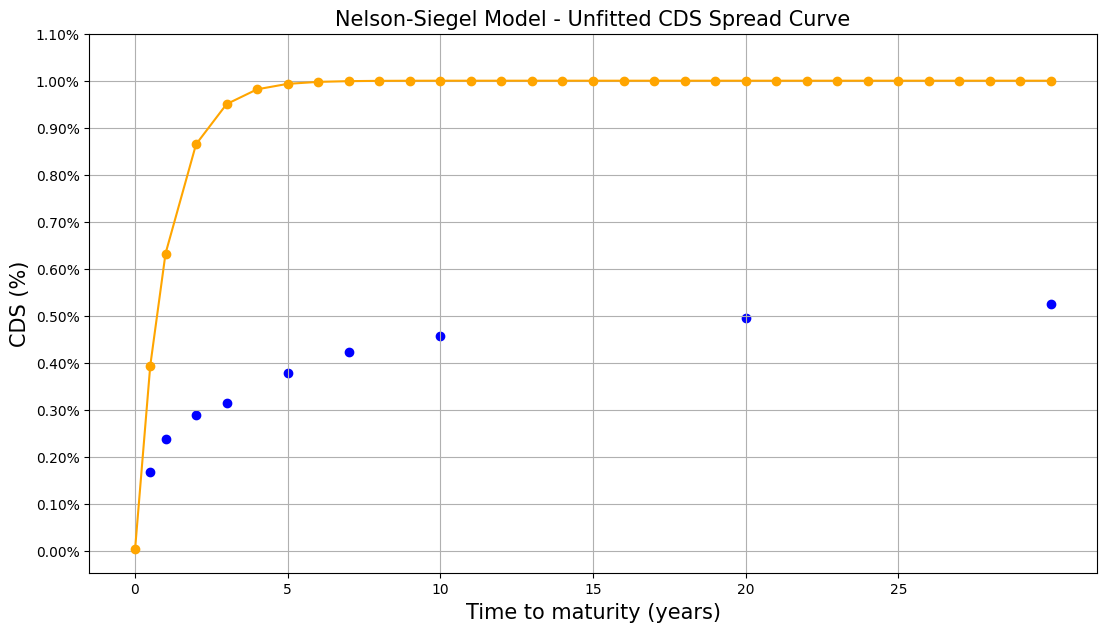

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

df = df.copy()

df["Y"] = round(df["CDS"]*100, 4)   # quoted CDS spread in percent units
df['N'] = round(df['NS']*100,4) # estimated CDS spread in percent units

fontsize = 15

fig, ax = plt.subplots(figsize=(13, 7)) # plots original axis
fig.patch.set_facecolor("white") # background label color
ax.set_facecolor("white") # graph background color

ax.set_title("Nelson-Siegel Model - Unfitted CDS Spread Curve", fontsize=fontsize)

X = df["Maturity"]
Y = df["Y"]
x = df["Maturity"]
y = df['N']

ax.plot(x, y, marker = "o", color="orange", label="NS")
ax.scatter(X, Y, marker = "o", color = "blue")
# plots datapoints within the graph
# use ax.plot for a connected scatterplot, linestyle = '-'
# use ax.plot for a line chart, marker = "", linestyle = '-'
ax.set_xlabel("Time to maturity (years)", fontsize=fontsize)
ax.set_ylabel("CDS (%)", fontsize=fontsize)

# Y values are already in percent units, so use xmax=100 for % y-axis format
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

ax.set_xticks(np.arange(0, 30, 5)) # first tick, last tick, gaps
ax.set_yticks(np.arange(0, 1.2, 0.1))

ax.grid(True)

plt.show()
# plots the observed CDS data and and initial CDS curve, constructed using guessed parameters

In [ ]:
df['Residual'] =  (df['CDS'] - df['NS'])**2 # squared fitting error
df2 = df[['Maturity','CDS','NS','Residual']]  
df2.style.format({'Maturity': '{:,.1f}'.format,'CDS': '{:,.2%}','NS': '{:,.2%}','Residual': '{:,.9f}'})
# observed and guessed data in a dataframe form

,Maturity,CDS,NS,Residual
0,0.0,nan%,0.00%,nan
1,0.5,0.17%,0.39%,0.000005151
2,1.0,0.24%,0.63%,0.000015495
3,2.0,0.29%,0.86%,0.000033261
4,3.0,0.31%,0.95%,0.000040366
5,4.0,nan%,0.98%,nan
6,5.0,0.38%,0.99%,0.000037909
7,6.0,nan%,1.00%,nan
8,7.0,0.42%,1.00%,0.000033286
9,8.0,nan%,1.00%,nan


In [ ]:
from scipy.optimize import fmin
import pandas as pd
import numpy as np

def myval(c):
    df3 = df.copy()
    df3['NS'] = (c[0])*(1-((1-np.exp(-df3['Maturity']/c[2]))/(df3['Maturity']/c[2])))+(c[1]*((((1-np.exp(-df3['Maturity']/c[2]))/(df3['Maturity']/c[2])))-(np.exp(-df3['Maturity']/c[2]))))
    df3['Residual'] =  (df3['CDS'] - df3['NS'])**2
    val = np.sum(df3['Residual'])
    print("[β0, β2, λ]=",c,", SUM:", val)
    return(val)

c = fmin(myval, [0.1, 0.1, 1])

# parameter optimization using the SciPy library
# source: https://docs.scipy.org/doc/scipy-1.16.1/reference/optimize.html

[β0, β2, λ]= [0.1 0.1 1. ] , SUM: 0.06595009302339831
[β0, β2, λ]= [0.105 0.1   1.   ] , SUM: 0.0717448868098343
[β0, β2, λ]= [0.1   0.105 1.   ] , SUM: 0.06717417249683538
[β0, β2, λ]= [0.1  0.1  1.05] , SUM: 0.06522088728283441
[β0, β2, λ]= [0.095      0.10333333 1.03333333] , SUM: 0.060758273505940624
[β0, β2, λ]= [0.09  0.105 1.05 ] , SUM: 0.05567830077966797
[β0, β2, λ]= [0.09333333 0.09833333 1.06666667] , SUM: 0.05739943168213053
[β0, β2, λ]= [0.08888889 0.10222222 1.11111111] , SUM: 0.05325832004020212
[β0, β2, λ]= [0.08333333 0.10333333 1.16666667] , SUM: 0.04762446297959931
[β0, β2, λ]= [0.07777778 0.10444444 1.13888889] , SUM: 0.04304290060190068
[β0, β2, λ]= [0.06666667 0.10666667 1.18333333] , SUM: 0.03397671011723063
[β0, β2, λ]= [0.06666667 0.11166667 1.2       ] , SUM: 0.03485715286107078
[β0, β2, λ]= [0.05444444 0.10944444 1.31666667] , SUM: 0.025275327138403483
[β0, β2, λ]= [0.03666667 0.11166667 1.45      ] , SUM: 0.015374257321223514
[β0, β2, λ]= [0.03       0.11666

In [ ]:
β0 = c[0]
β2 = c[1]
λ = c[2]

print("[β0, β2, λ]=", [c[0].round(4), c[1].round(4), c[2].round(4)])
# presentation of the optimized parameters

[β0, β2, λ]= [np.float64(0.005), np.float64(0.0), np.float64(0.9013)]


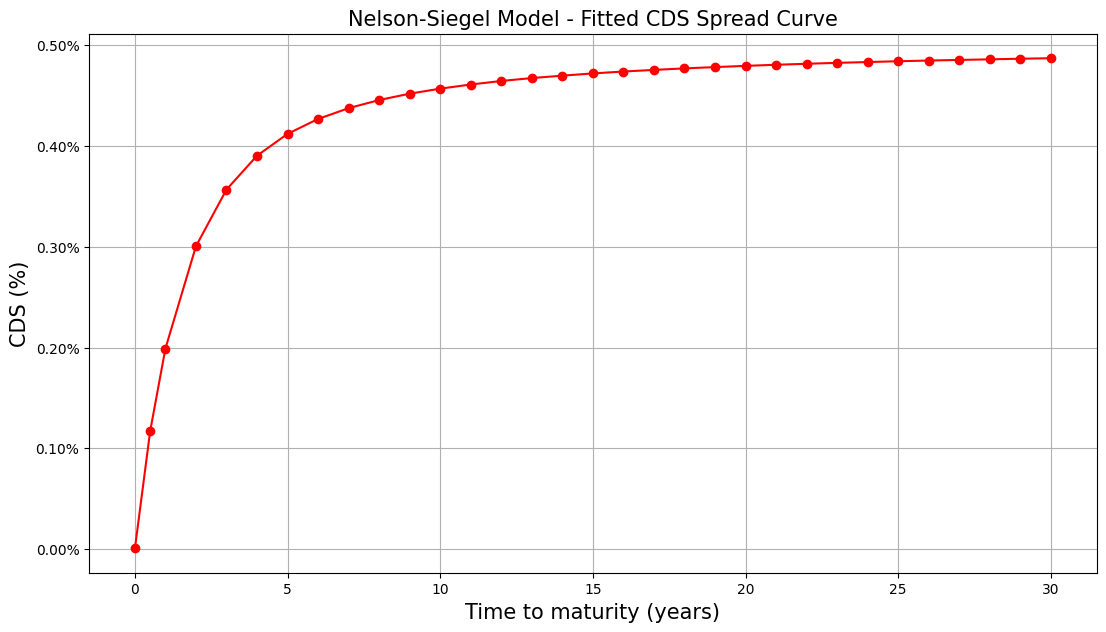

In [ ]:
# fitted CDS spread curve => adjusted Nelson-Siegel
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


df4 = df2.copy()
df4['NS'] = (β0*(1-((1-np.exp(-df['Maturity']/λ))/(df['Maturity']/λ))))+(β2*((((1-np.exp(-df['Maturity']/λ))/(df['Maturity']/λ)))-(np.exp(-df['Maturity']/λ))))
sf4 = df.copy()
sf4["N"] = round(df4["NS"]*100, 4)   # fitted CDS in percent units

fontsize = 15

fig, ax = plt.subplots(figsize=(13, 7)) # plots original axis
fig.patch.set_facecolor("white") # background label color
ax.set_facecolor("white") # graph background color

ax.set_title("Nelson-Siegel Model - Fitted CDS Spread Curve", fontsize=fontsize)

X = df["Maturity"]
Y = sf4["N"]

ax.plot(X, Y, marker="o", color="red", linestyle="-")
# plots datapoints within the graph
# use ax.plot for a connected scatterplot, linestyle = '-'
# use ax.plot for a line chart, marker = "", linestyle = '-'
ax.set_xlabel("Time to maturity (years)", fontsize=fontsize)
ax.set_ylabel("CDS (%)", fontsize=fontsize)

# Y values are already in percent units, so use xmax=100 for % y-axis format
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))

ax.set_xticks(np.arange(0, 35, 5)) # first tick, last tick, gaps
ax.set_yticks(np.arange(0, 0.6, 0.1))

ax.grid(True)

plt.show()
# visualization of the fitted CDS spread curve (optimized parameters)

In [ ]:
# fitted vs quoted market CDS spreads in a dataframe
ns_curve = df4.style.format({'Maturity': '{:,.1f}'.format,'CDS': '{:,.2%}','NS': '{:,.2%}'})
ns_curve

,Maturity,CDS,NS,Residual
0,0.0,nan%,0.00%,nan
1,0.5,0.17%,0.12%,0.000005
2,1.0,0.24%,0.20%,0.000015
3,2.0,0.29%,0.30%,0.000033
4,3.0,0.31%,0.36%,0.000040
5,4.0,nan%,0.39%,nan
6,5.0,0.38%,0.41%,0.000038
7,6.0,nan%,0.43%,nan
8,7.0,0.42%,0.44%,0.000033
9,8.0,nan%,0.45%,nan


In [23]:
ns_curve.to_excel('nss_cds_curve.xlsx', engine='openpyxl', index=False)
# export output to Excel